# Per-feed/band statistics & calibrator investigation

Read-only inspection of the SQLite database. No pipeline state is modified.

Walks through:
1. Coverage — what fraction of obsids have populated stats?
2. Time series — drift in noise / Tsys / tau over MJD
3. Feed × band heatmaps — dead/bad cells
4. Per-source-group distributions
5. Per-scan drill-down (one obsid, from HDF5)
6. Calibrator flux time series + active model overlay

In [ ]:
import os, sys
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO not in sys.path:
    sys.path.insert(0, REPO)

DB_PATH = os.path.join(REPO, 'databases', 'COMAP_manchester.db')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from modules.diagnostics import stats_queries as sq
from modules.diagnostics import stats_plots as sp

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

## 1. Coverage

In [2]:
qf = sq.load_quality_flags(DB_PATH)
summary = sq.load_observation_summary(DB_PATH)
print(f'quality_flags rows: {len(qf):,}  unique obsids: {qf.obsid.nunique():,}')
print(f'observation_summary rows: {len(summary):,}')
qf.head()

quality_flags rows: 2,748,205  unique obsids: 17,623
observation_summary rows: 0


,obsid,feed,band,is_good,comment,filtered_red_noise,filtered_white_noise,filtered_auto_rms,filtered_noise_index,unfiltered_red_noise,unfiltered_white_noise,unfiltered_auto_rms,unfiltered_noise_index,n_spikes,n_nan_values,mean_atm_temp,source,source_group,utc_start,level2_path,mjd
0,3918,0,0,True,Observer Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,TauA,Calibrator,2019-02-11-23:56:04,NaN,58525.997269
1,3918,0,1,True,Observer Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,TauA,Calibrator,2019-02-11-23:56:04,NaN,58525.997269
2,3918,0,2,True,Observer Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,TauA,Calibrator,2019-02-11-23:56:04,NaN,58525.997269
3,3918,0,3,True,Observer Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,TauA,Calibrator,2019-02-11-23:56:04,NaN,58525.997269
4,3918,0,4,True,Observer Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,TauA,Calibrator,2019-02-11-23:56:04,NaN,58525.997269


In [3]:
coverage = sq.summarize_coverage(qf, summary if not summary.empty else None)
coverage.T  # transpose for readability

source_group,CO,Calibrator,Foreground,Galactic,Other,SkyDip,NaN
n_obsids,561.0,6.527000e+03,2088.000000,2693.000000,1686.000000,4003.000000,65.0
n_rows,85272.0,1.025973e+06,327232.000000,429856.000000,256272.000000,613720.000000,9880.0
frac_bad_flag,0.0,4.878101e-02,0.032784,0.057847,0.006493,0.015848,0.0
frac_filtered_red_noise,0.0,3.899040e-01,0.307928,0.623304,0.000000,0.157039,0.0
frac_filtered_white_noise,0.0,3.899040e-01,0.307928,0.623304,0.000000,0.157039,0.0
frac_filtered_auto_rms,0.0,3.909684e-01,0.308429,0.628115,0.000000,0.157766,0.0
frac_filtered_noise_index,0.0,3.899040e-01,0.307928,0.623304,0.000000,0.157039,0.0
frac_unfiltered_red_noise,0.0,3.897588e-01,0.307928,0.623195,0.000000,0.156790,0.0
frac_unfiltered_white_noise,0.0,3.897588e-01,0.307928,0.623195,0.000000,0.156790,0.0
frac_unfiltered_auto_rms,0.0,3.908232e-01,0.308429,0.628006,0.000000,0.157516,0.0


## 2. Time series

One stat per panel. Coloured by feed; pick a single band to avoid overplot.

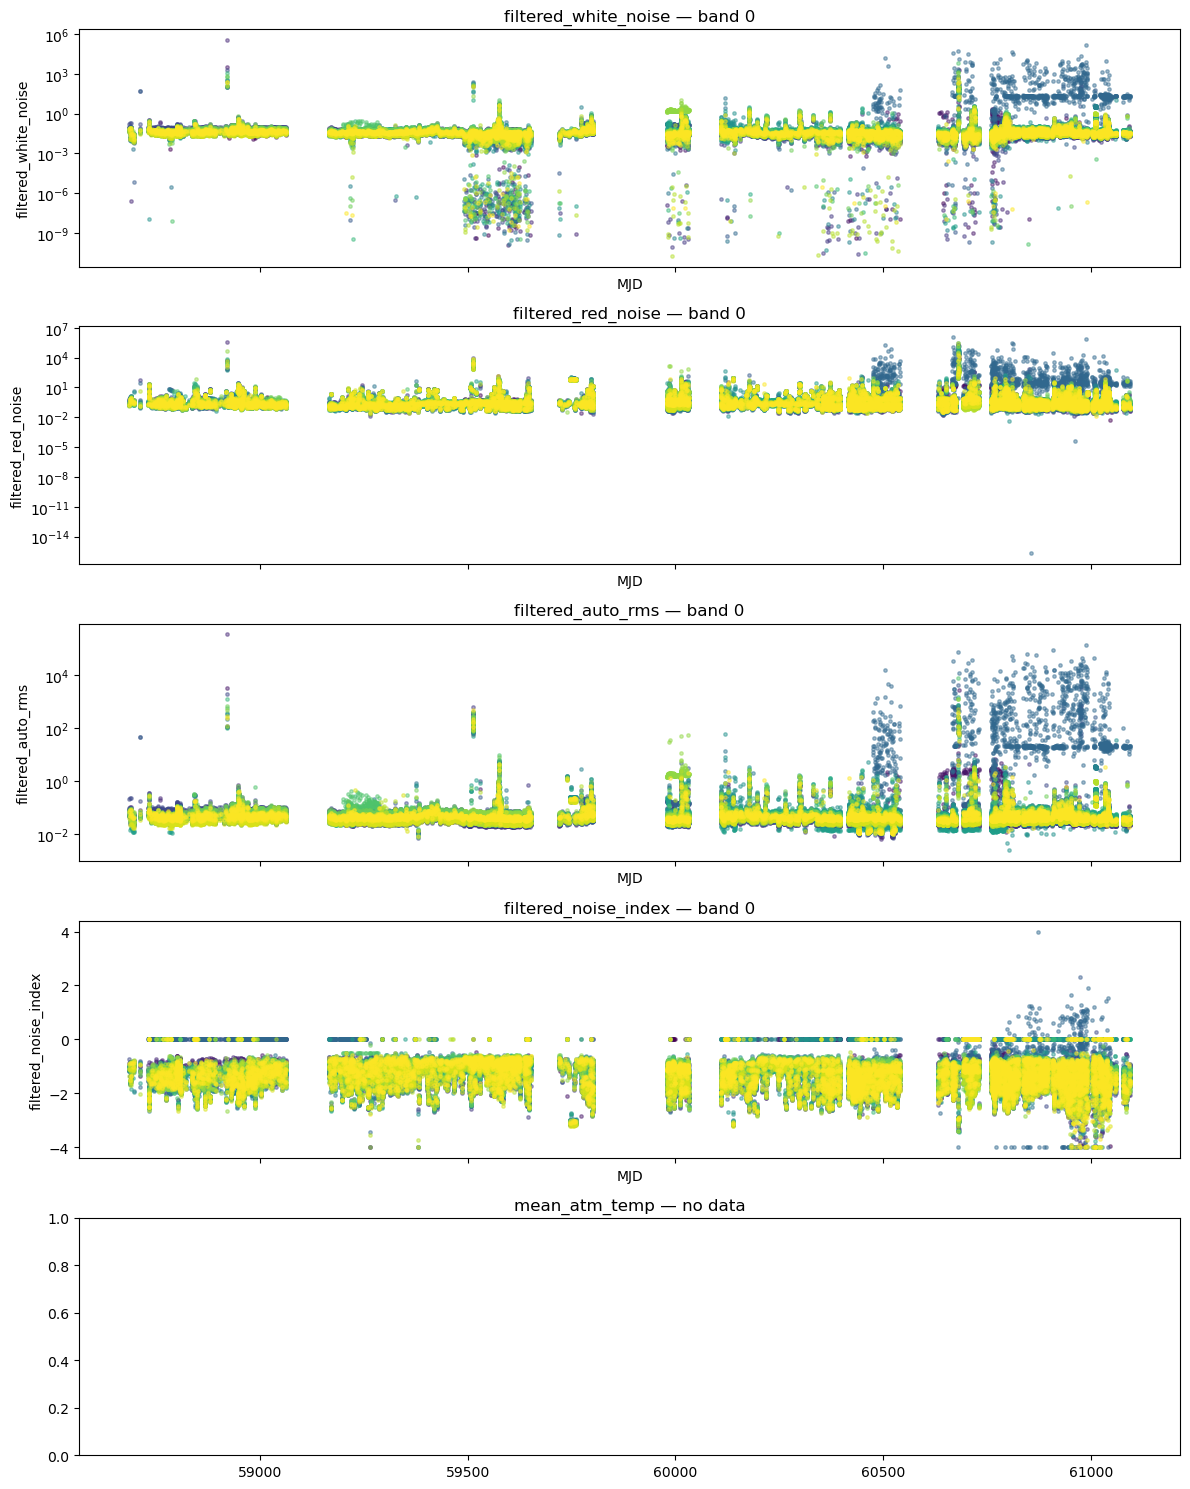

In [4]:
BAND_FOR_TIMESERIES = 0
STATS_FOR_TIMESERIES = [
    ('filtered_white_noise', True),
    ('filtered_red_noise', True),
    ('filtered_auto_rms', True),
    ('filtered_noise_index', False),
    ('mean_atm_temp', False),
]
fig, axes = plt.subplots(len(STATS_FOR_TIMESERIES), 1, figsize=(12, 3*len(STATS_FOR_TIMESERIES)), sharex=True)
for ax, (stat, log_y) in zip(axes, STATS_FOR_TIMESERIES):
    sp.plot_timeseries(qf, stat, group_by='feed', band=BAND_FOR_TIMESERIES, ax=ax, log_y=log_y)
plt.tight_layout()

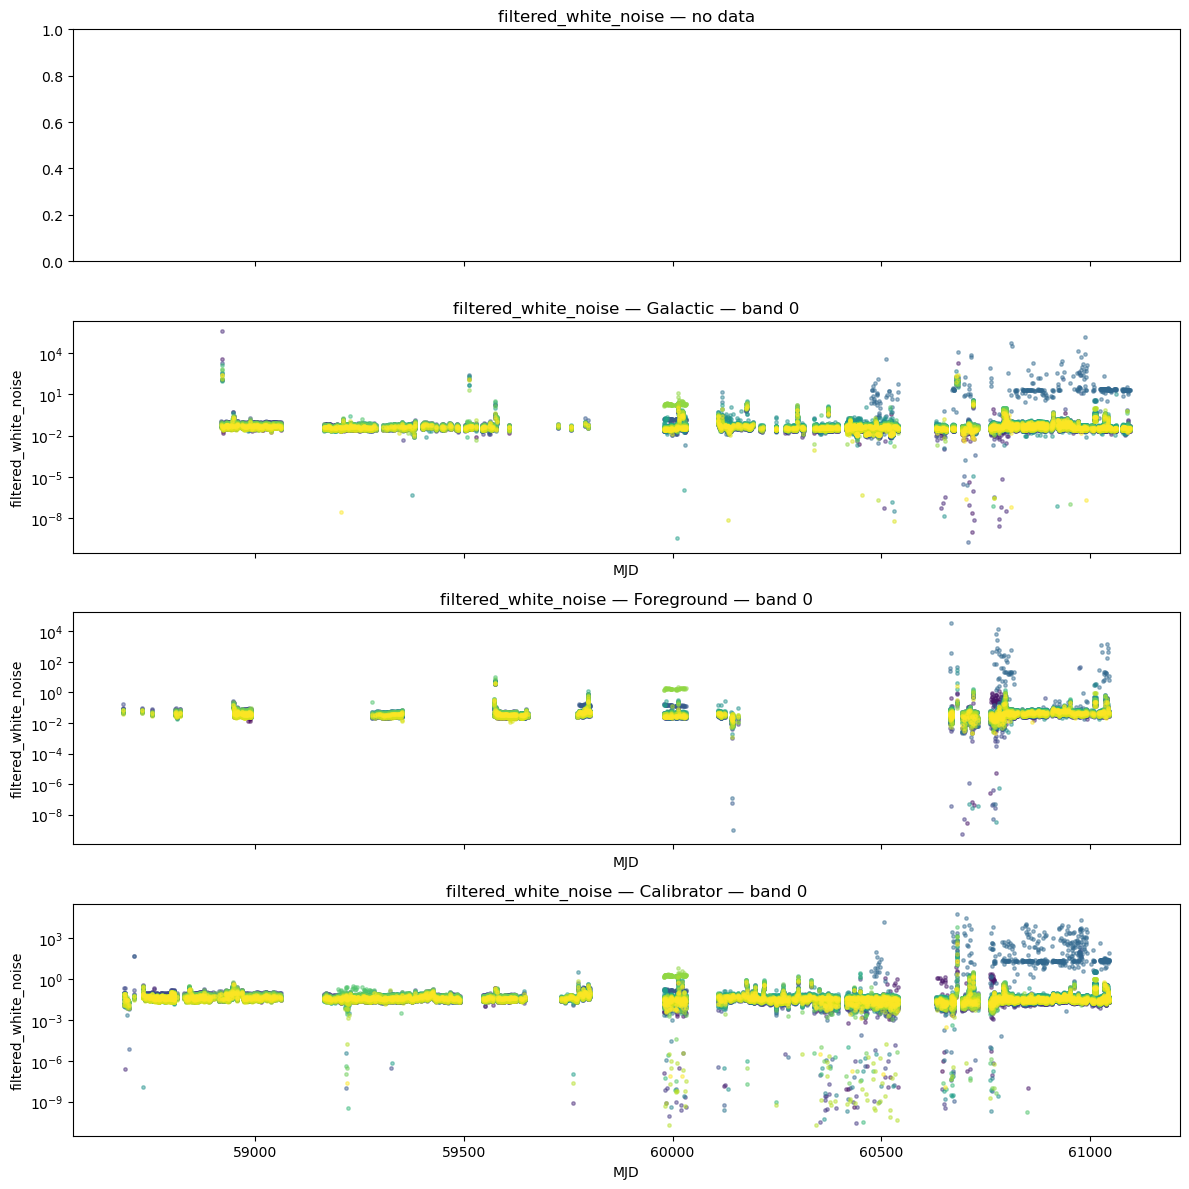

In [5]:
# Split filtered_white_noise by source group
groups = [g for g in ['CO', 'Galactic', 'Foreground', 'Calibrator'] if g in qf.source_group.unique()]
fig, axes = plt.subplots(len(groups), 1, figsize=(12, 3*len(groups)), sharex=True)
if len(groups) == 1:
    axes = [axes]
for ax, g in zip(axes, groups):
    sp.plot_timeseries(qf, 'filtered_white_noise', group_by='feed', band=BAND_FOR_TIMESERIES, source_group=g, ax=ax, log_y=True)
plt.tight_layout()

In [6]:
# Observation-level summary stats (if observation_summary populated)
if not summary.empty:
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    for ax, col in zip(axes, ['median_tsys', 'mean_tau', 'calibrator_flux']):
        if col in summary.columns:
            sub = summary.dropna(subset=[col, 'mjd'])
            for g, seg in sub.groupby('source_group', dropna=False):
                ax.scatter(seg['mjd'], seg[col], s=6, alpha=0.5, label=str(g))
            ax.set_ylabel(col)
            ax.legend(fontsize=7, ncol=3)
    axes[-1].set_xlabel('MJD')
    plt.tight_layout()
else:
    print('observation_summary table is empty/missing — skipping.')

observation_summary table is empty/missing — skipping.


## 3. Feed × band heatmaps

Median stat across all obsids per (feed, band) cell. Numbers are obsid counts.

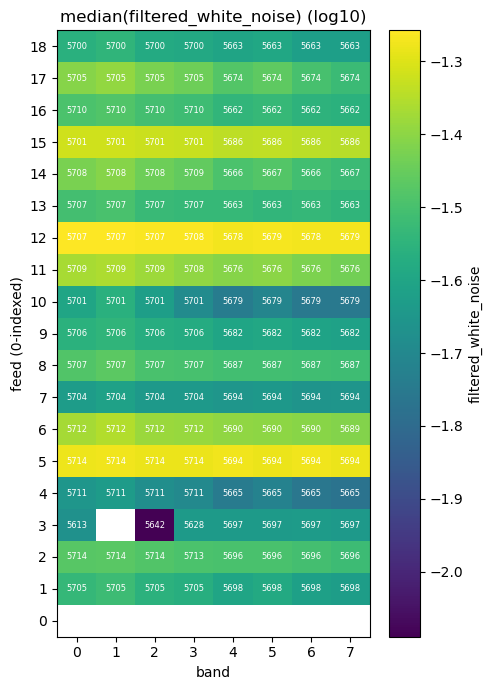

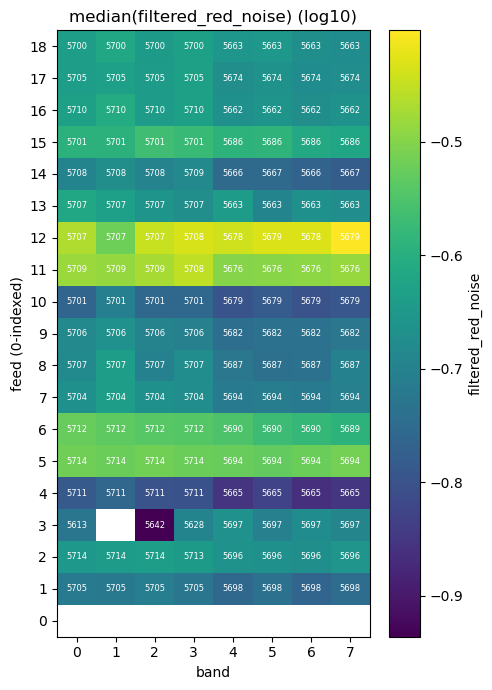

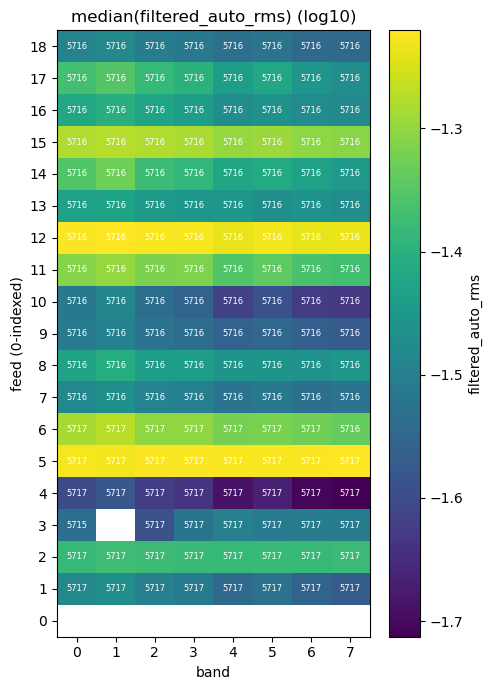

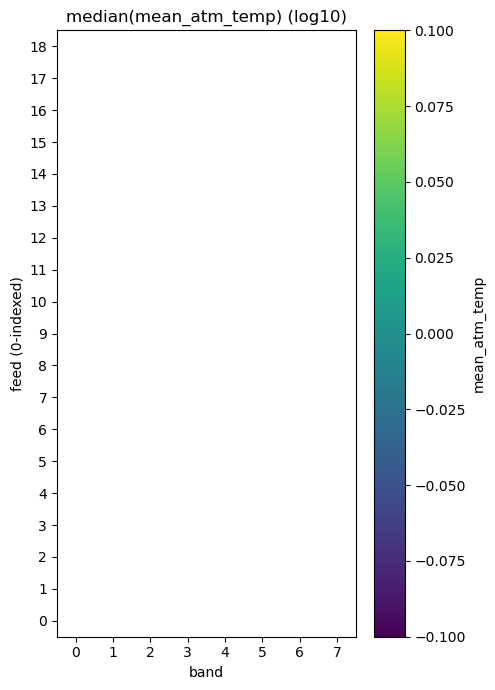

In [7]:
for stat in ['filtered_white_noise', 'filtered_red_noise', 'filtered_auto_rms', 'mean_atm_temp']:
    fig, ax = plt.subplots(figsize=(5, 7))
    sp.plot_feed_band_heatmap(qf, stat, agg='median', ax=ax, log_color=True)
    plt.tight_layout()
    plt.show()

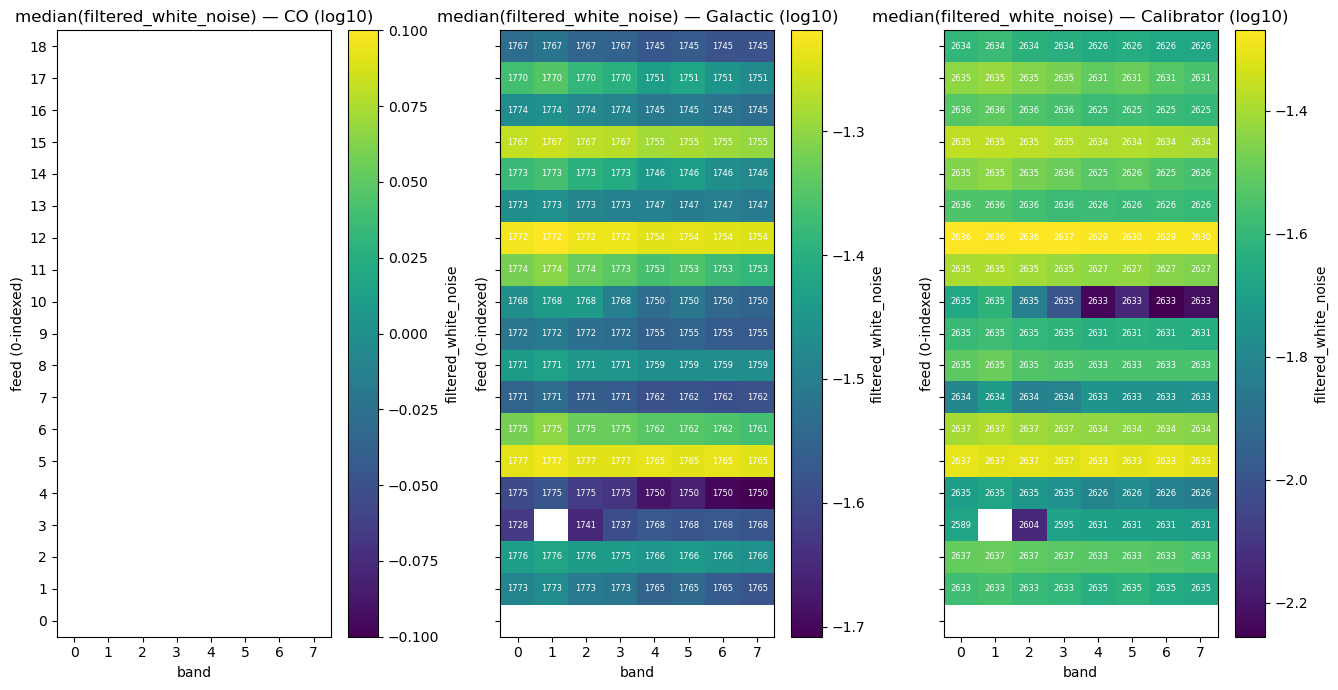

In [8]:
# Per-source-group heatmap of filtered_white_noise
groups = [g for g in ['CO', 'Galactic', 'Calibrator'] if g in qf.source_group.unique()]
fig, axes = plt.subplots(1, len(groups), figsize=(4.5*len(groups), 7), sharey=True)
if len(groups) == 1:
    axes = [axes]
for ax, g in zip(axes, groups):
    sp.plot_feed_band_heatmap(qf, 'filtered_white_noise', agg='median', source_group=g, ax=ax, log_color=True)
plt.tight_layout()

## 4. Distributions by source group

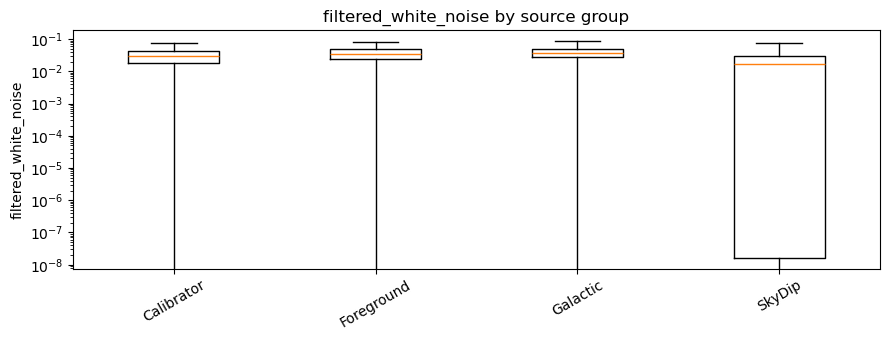

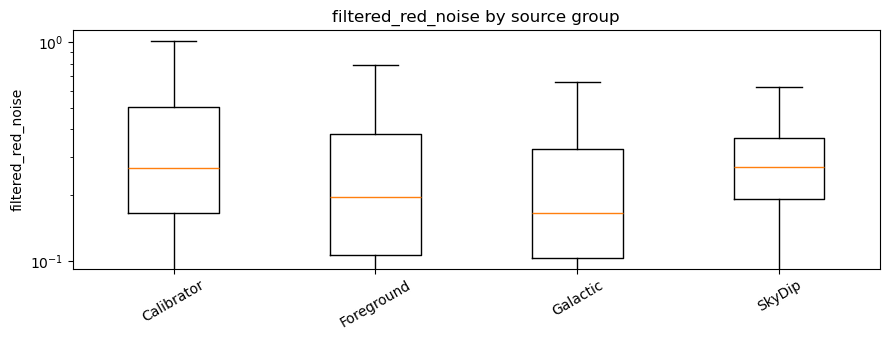

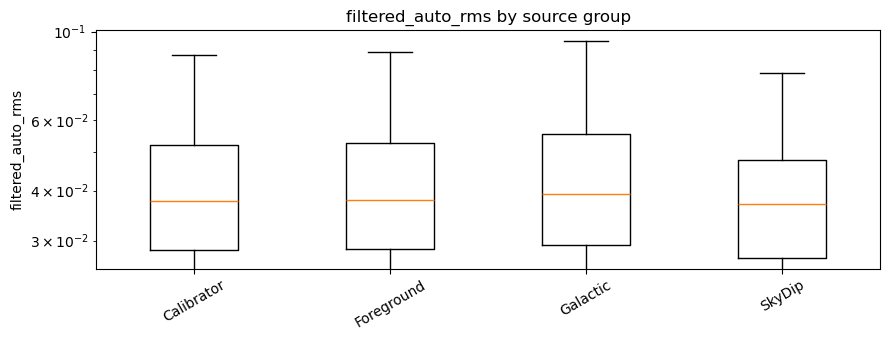

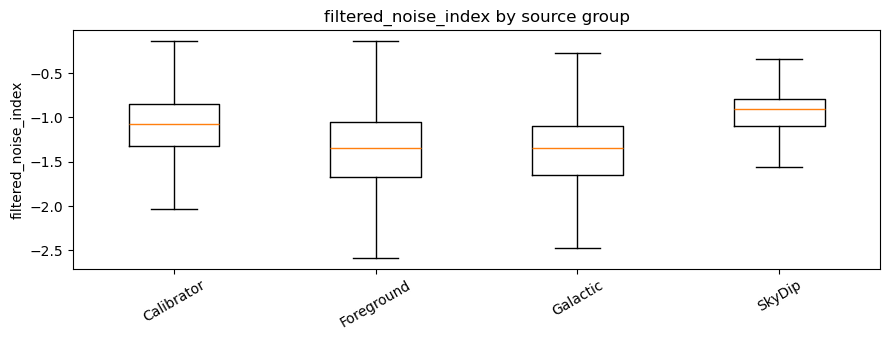

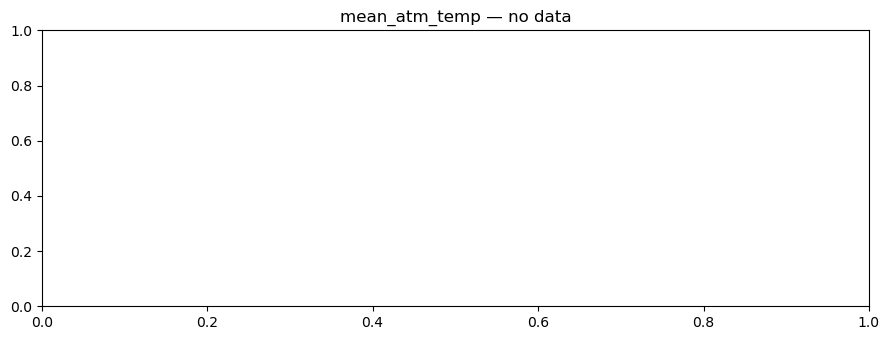

In [9]:
for stat, log_y in [
    ('filtered_white_noise', True),
    ('filtered_red_noise', True),
    ('filtered_auto_rms', True),
    ('filtered_noise_index', False),
    ('mean_atm_temp', False),
]:
    fig, ax = plt.subplots(figsize=(9, 3.5))
    sp.plot_source_group_distributions(qf, stat, ax=ax, log_y=log_y)
    plt.tight_layout()
    plt.show()

## 4b. Per-feed box plots in hex layout

One mini box plot per feed, arranged in the 19-feed hexagon. Customise
`HEX_LAYOUT` below to match the physical pixel positions — keys are
feed indices (0-18), values are `(x, y)` in hex units. Larger `y` is
toward the top of the figure; offset `x` by 0.5 between adjacent rows
to get the hex packing.

In [ ]:
# Edit this dict to set which feed sits at which hex position.
# Default mirrors stats_plots.DEFAULT_HEX_LAYOUT (rows of 3-4-5-4-3).
HEX_LAYOUT = {
    0: (1.0,  2.0), 1: (2.0,  2.0), 2: (3.0,  2.0),
    3: (0.5,  1.0), 4: (1.5,  1.0), 5: (2.5,  1.0), 6: (3.5,  1.0),
    7: (0.0,  0.0), 8: (1.0,  0.0), 9: (2.0,  0.0), 10: (3.0, 0.0), 11: (4.0, 0.0),
    12: (0.5, -1.0), 13: (1.5, -1.0), 14: (2.5, -1.0), 15: (3.5, -1.0),
    16: (1.0, -2.0), 17: (2.0, -2.0), 18: (3.0, -2.0),
}

HEX_BAND = 0
HEX_SOURCE_GROUP = None   # e.g. 'Galactic', 'Calibrator', or None for all

for stat, log_y in [
    ('filtered_white_noise', True),
    ('filtered_red_noise',   True),
    ('filtered_auto_rms',    True),
    ('filtered_noise_index', False),
    ('mean_atm_temp',        False),
]:
    fig = plt.figure(figsize=(11, 9))
    sp.plot_feed_hex_boxplots(
        qf, stat,
        hex_layout=HEX_LAYOUT,
        band=HEX_BAND,
        source_group=HEX_SOURCE_GROUP,
        log_y=log_y,
        fig=fig,
    )
    plt.show()

## 4c. Observation counts

Observation counts per source group, then per individual source within
Galactic / Calibrator / Foreground. SkyDip is excluded.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sp.plot_obsids_per_source_group(qf, exclude_groups=('SkyDip',), ax=ax)
plt.tight_layout()
plt.show()

# Bars show total observations per source; the narrower overlay shows
# how many would survive MapMaking's obsid-level flag check
# (level2_path present AND at least one (feed,band) is_good=True).
# This is an SQL upper bound — HDF5 dataset checks happen later.
for grp in ('Galactic', 'Calibrator', 'Foreground'):
    sp.plot_obsids_per_source(
        qf, source_group=grp, log_y=False, show_mapmaking_pass=True,
    )
    plt.tight_layout()
    plt.show()

## 5. Per-scan drill-down (HDF5)

Pick one obsid per source group and open its Level-2 file to look at per-scan noise stats.

In [10]:
# Choose obsids with the most populated noise stats per group
candidates = (qf.dropna(subset=['filtered_white_noise', 'level2_path'])
                .groupby(['source_group', 'obsid'])
                .size().reset_index(name='n'))
best = candidates.sort_values(['source_group', 'n'], ascending=[True, False]).groupby('source_group').head(1)
best = best.merge(qf[['obsid', 'level2_path']].drop_duplicates('obsid'), on='obsid', how='left')
best

,source_group,obsid,n,level2_path
0,Calibrator,7014,152,/scratch/nas_comap1/sharper/COMAP/level2_data_...
1,Foreground,7002,152,/scratch/nas_core2/sharper_nas_core/COMAP/leve...
2,Galactic,11755,152,/scratch/nas_core2/sharper_nas_core/COMAP/leve...
3,SkyDip,8591,152,/scratch/nas_core2/sharper/COMAP/level2_data_2...


In [11]:
# Set this manually if you want a specific obsid
PER_SCAN_OBSID = None
PER_SCAN_BAND = 0
PER_SCAN_CHANNEL = 0

if PER_SCAN_OBSID is None and not best.empty:
    PER_SCAN_OBSID = int(best.iloc[0]['obsid'])

if PER_SCAN_OBSID is not None:
    path_row = qf[qf['obsid'] == PER_SCAN_OBSID]['level2_path'].dropna().head(1)
    if path_row.empty or not os.path.exists(path_row.iloc[0]):
        print(f'Level-2 file not available locally for obsid {PER_SCAN_OBSID}; skip.')
    else:
        path = path_row.iloc[0]
        per_scan = sq.load_per_scan_noise_from_hdf5(path)
        print(f'Loaded {len(per_scan):,} rows from {path}')
        print('columns:', list(per_scan.columns))
        stat_cols = [c for c in per_scan.columns if c not in ('feed','band','channel','scan')]
        for stat in stat_cols[:4]:
            fig, ax = plt.subplots(figsize=(11, 4))
            sp.plot_per_scan(per_scan, stat, band=PER_SCAN_BAND, channel=PER_SCAN_CHANNEL, ax=ax)
            plt.tight_layout(); plt.show()

Level-2 file not available locally for obsid 7014; skip.


In [12]:
# Sanity check: per-scan mean from HDF5 should approximate the SQL aggregate
if PER_SCAN_OBSID is not None and 'per_scan' in dir():
    sql_row = qf[(qf.obsid == PER_SCAN_OBSID) & (qf.feed == 0) & (qf.band == PER_SCAN_BAND)]
    if not sql_row.empty:
        print('SQL aggregate (feed=0, band=%d):' % PER_SCAN_BAND)
        print(sql_row[sq.NOISE_COLUMNS].iloc[0])
    if not per_scan.empty:
        hdf_mean = (per_scan[(per_scan.feed==0) & (per_scan.band==PER_SCAN_BAND)]
                              .drop(columns=['feed','band','channel','scan']).mean(numeric_only=True))
        print('\nHDF5 mean across scans/channels (feed=0, band=%d):' % PER_SCAN_BAND)
        print(hdf_mean)

## 6. Calibrator measurements

Per-element measured flux vs MJD with the active model overlay.

In [13]:
cal_df = sq.load_calibration_flux(DB_PATH)
model_df = sq.load_calibration_model(DB_PATH)
print('calibration_flux rows:', len(cal_df))
print('calibration_model_fit rows:', len(model_df))
if not cal_df.empty:
    print('sources:', sorted(cal_df['source'].unique()))
if not model_df.empty:
    print('model types in use:', model_df['model_type'].value_counts().to_dict())

calibration_flux rows: 0
calibration_model_fit rows: 0


In [14]:
if not cal_df.empty:
    CALIBRATOR = 'TauA' if 'TauA' in cal_df['source'].unique() else cal_df['source'].iloc[0]
    BAND = 0
    CHANNEL = 0
    feeds = sorted(cal_df[cal_df['source']==CALIBRATOR]['feed'].unique())[:6]
    fig, axes = plt.subplots(len(feeds), 1, figsize=(11, 3*len(feeds)), sharex=True)
    if len(feeds) == 1:
        axes = [axes]
    for ax, feed in zip(axes, feeds):
        sp.plot_calibrator_timeseries(cal_df, CALIBRATOR, feed=feed, band=BAND, channel=CHANNEL, model_df=model_df, ax=ax)
    plt.tight_layout()
else:
    print('No calibration_flux data in this DB.')

No calibration_flux data in this DB.


In [15]:
# Residuals: (measured - model) / error, summarised per (feed, band)
if not cal_df.empty and not model_df.empty:
    rows = []
    for (src, feed, band, channel), seg in cal_df.dropna(subset=['measured_flux','mjd']).groupby(['source','feed','band','channel']):
        row = model_df[(model_df.feed==feed) & (model_df.band==band) & (model_df.channel==channel)]
        if len(row) != 1:
            continue
        curve = sp._evaluate_model(row.iloc[0], seg['mjd'].values)
        if curve is None:
            continue
        resid = (seg['measured_flux'].values - curve)
        rows.append({'source': src, 'feed': feed, 'band': band, 'channel': channel,
                     'n': len(seg), 'mean_resid': np.nanmean(resid), 'std_resid': np.nanstd(resid)})
    resid_df = pd.DataFrame(rows)
    print(resid_df.head(20))
else:
    print('Skip residuals — need both calibration_flux and calibration_model_fit.')

Skip residuals — need both calibration_flux and calibration_model_fit.
